In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
import json
from PIL import Image
from collections import Counter

In [2]:
#after upload the dataset to google drive, mount on google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#locate the uploaded dataset
!find "/content/drive/MyDrive" -name "Clouds-1000.zip"

/content/drive/MyDrive/Clouds-1000.zip


In [4]:
#use the path above as the dataset path and open zip file
zip_path = "/content/drive/MyDrive/Clouds-1000.zip"
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("dataset")

In [5]:
#check the folders in the dataset
print(os.listdir("dataset/Clouds-1000"))

['obj_class_to_machine_color.json', 'all_images_and_labels', 'meta.json']


In [6]:
#check the folders inside the all_images_and_labels folder
base_path = "dataset/Clouds-1000/all_images_and_labels"

print(os.listdir(base_path))

['images', 'masks']


In [16]:
# define two variable and print some sample content
img_dir = "dataset/Clouds-1000/all_images_and_labels/images"
mask_dir = "dataset/Clouds-1000/all_images_and_labels/masks"
files1 = os.listdir(img_dir)
files2 = os.listdir(mask_dir)
print(files1[:5])
print(files2[:5])

['2021-05-04_10-08-00.jpg', '2021-05-04_12-33-00.jpg', '2021-05-05_12-30-00.jpg', '2021-03-05-11-40.jpg', '2021-03-04-06-37.jpg']
['2021-04-09-08-00.jpg.json', '10-46-00.jpg.json', '2021-03-05-11-29.jpg.json', '2021-04-09-10-36.jpg.json', '2021-05-04_14-33-00.jpg.json']


In [17]:
#sample data inspection
#print the first class label
img_file = os.listdir(img_dir)[0]
mask_file = img_file + ".json"
#create full image & mask path
img_path = os.path.join(img_dir, img_file)
mask_path = os.path.join(mask_dir, mask_file)
#load the image
image = Image.open(img_path).convert("RGB")
#load json file and convert it into a python dictionary
with open(mask_path, "r") as f:
    annotation = json.load(f)

print(annotation["objects"][0]["classTitle"])

Estratocumuliformes


In [12]:
# Polygon annotations were converted into bounding boxes to inspect object spatial properties
# and prepare the dataset for object detection training.
# Extract polygon coordinates and convert them into a bounding box around the cloud object
points = annotation["objects"][0]["points"]["exterior"]
#Extract all x-coordinates
xs = [p[0] for p in points]
#Extract all y-coordinates
ys = [p[1] for p in points]
#Compute left/right boundaries
x_min, x_max = min(xs), max(xs)
#Compute top/bottom boundaries
y_min, y_max = min(ys), max(ys)
print(points[:5])

[[0, 941], [122, 960], [288, 973], [407, 982], [536, 960]]


In [13]:
# Number of samples
num_samples = len(os.listdir(img_dir))

# Number of features
img = Image.open(img_path)

img_array = np.array(img)

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print("Shape:", img_array.shape)

# Display the first few rows of the dataframe to show the structure

sample_file = os.path.join(mask_dir, files2[0])

with open(sample_file, "r") as f:
    data = json.load(f)
print("Example data:")
print(data)


Number of samples: 996
Shape: (1944, 2592, 3)
Example data:
{'description': '', 'tags': [], 'size': {'height': 1944, 'width': 2592}, 'objects': [{'id': 818030294, 'classId': 8907992, 'description': '', 'geometryType': 'polygon', 'labelerLogin': 'juharrais1', 'createdAt': '2021-08-03T17:45:49.547Z', 'updatedAt': '2021-08-03T17:45:49.547Z', 'tags': [], 'classTitle': 'Cirriformes', 'points': {'exterior': [[215, 0], [211, 75], [245, 131], [259, 186], [280, 253], [310, 292], [379, 338], [450, 372], [503, 423], [561, 481], [641, 534], [671, 506], [671, 458], [639, 407], [595, 361], [544, 306], [515, 266], [489, 204], [563, 225], [609, 266], [699, 308], [719, 306], [731, 266], [733, 225], [715, 179], [694, 117], [666, 39], [643, 0]], 'interior': []}}, {'id': 818030293, 'classId': 8907990, 'description': '', 'geometryType': 'polygon', 'labelerLogin': 'juharrais1', 'createdAt': '2021-08-03T17:45:49.547Z', 'updatedAt': '2021-08-03T17:45:49.547Z', 'tags': [], 'classTitle': 'Estratocumuliformes', 

In [14]:
# Check for missing values
# convert image names to expected mask names
images = set(os.listdir(img_dir))
masks = set(os.listdir(mask_dir))
expected_masks = {img + ".json" for img in images}

missing_masks = expected_masks - masks
missing_images = {mask.replace(".json", "") for mask in masks} - images

print("Missing masks:", len(missing_masks))
print("Missing images:", len(missing_images))

#check for empty json file
empty_labels = []

for file in os.listdir(mask_dir):
    path = os.path.join(mask_dir, file)

    with open(path, "r") as f:
        data = json.load(f)

    if len(data.get("objects", [])) == 0:
        empty_labels.append(file)

print("Empty annotation files:", len(empty_labels))

#check for broken image
broken_images = []

for file in os.listdir(img_dir)[:100]:
    path = os.path.join(img_dir, file)
    try:
        img = Image.open(path)
        img.verify()
    except:
        broken_images.append(file)

print("Broken images:", len(broken_images))

#Summary of dataset health
print("Total images:", len(images))
print("Total masks:", len(masks))
print("Missing masks:", len(missing_masks))
print("Missing images:", len(missing_images))
print("Empty labels:", len(empty_labels))

# Handling missing values
# Example: Replacing NaN values with the mean value of the column
# df.fillna(df.mean(), inplace=True)

# Your code for handling missing values goes here




Missing masks: 0
Missing images: 0
Empty annotation files: 0
Broken images: 0
Total images: 996
Total masks: 996
Missing masks: 0
Missing images: 0
Empty labels: 0


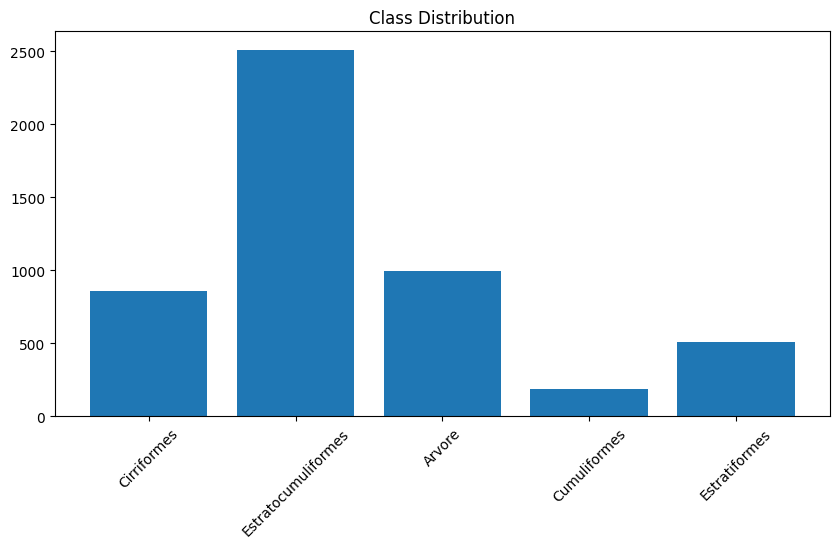

In [15]:
# Feature Distributions

# Class distribution also can be for bias check

classes = []

for file in os.listdir(mask_dir):
    path = os.path.join(mask_dir, file)

    with open(path, "r") as f:
        data = json.load(f)

    for obj in data["objects"]:
        classes.append(obj["classTitle"])

counter = Counter(classes)

plt.figure(figsize=(10,5))
plt.bar(counter.keys(), counter.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

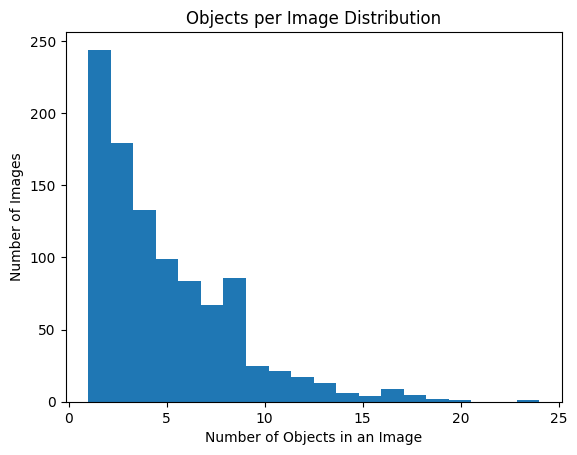

In [19]:
# Number of objects per image also can be for bias check
obj_counts = []

for file in os.listdir(mask_dir):
    path = os.path.join(mask_dir, file)

    with open(path, "r") as f:
        data = json.load(f)

    obj_counts.append(len(data["objects"]))

plt.hist(obj_counts, bins=20)
plt.title("Objects per Image Distribution")
plt.xlabel("Number of Objects in an Image")
plt.ylabel("Number of Images")
plt.show()

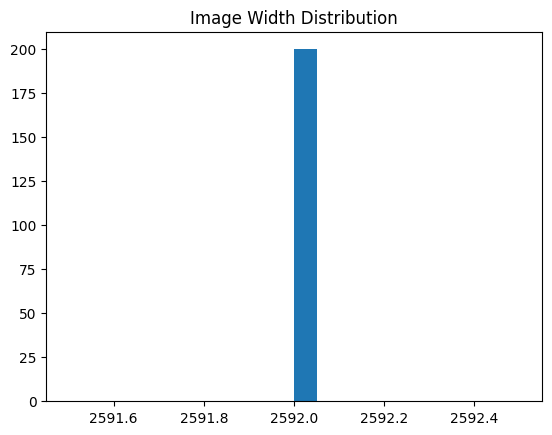

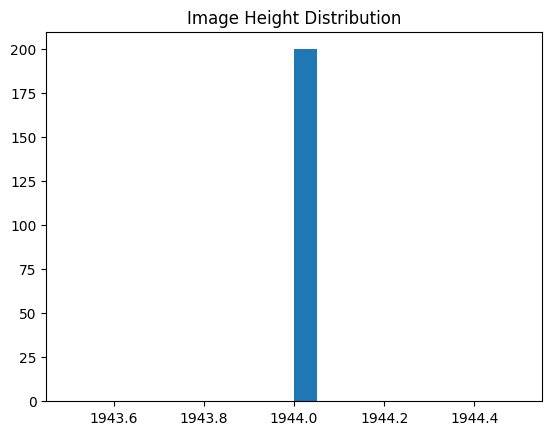

In [ ]:
# Image size distribution
img_dir = "dataset/Clouds-1000/all_images_and_labels/images"

heights = []
widths = []

for file in os.listdir(img_dir)[:200]:
    img = Image.open(os.path.join(img_dir, file))
    w, h = img.size

    widths.append(w)
    heights.append(h)

plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

plt.hist(heights, bins=20)
plt.title("Image Height Distribution")
plt.show()

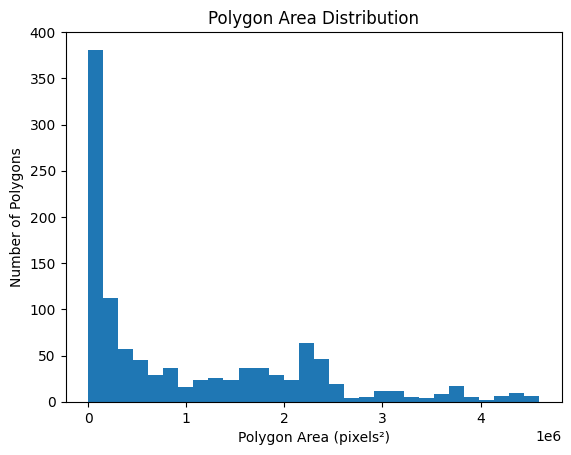

In [21]:
# Polygon size distribution
areas = []

for file in os.listdir(mask_dir)[:200]:
    path = os.path.join(mask_dir, file)

    with open(path, "r") as f:
        data = json.load(f)

    for obj in data["objects"]:
        points = obj["points"]["exterior"]

        xs = [p[0] for p in points]
        ys = [p[1] for p in points]

        area = (max(xs) - min(xs)) * (max(ys) - min(ys))
        areas.append(area)

plt.hist(areas, bins=30)
plt.title("Polygon Area Distribution")
plt.xlabel("Polygon Area (pixels²)")
plt.ylabel("Number of Polygons")
plt.show()

In [27]:
# Correlation
from collections import defaultdict

class_areas = defaultdict(list)

for file in os.listdir(mask_dir)[:300]:
    path = os.path.join(mask_dir, file)

    with open(path, "r") as f:
        data = json.load(f)

    for obj in data["objects"]:
        cls = obj["classTitle"]
        pts = obj["points"]["exterior"]

        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]

        area = (max(xs)-min(xs)) * (max(ys)-min(ys))

        class_areas[cls].append(area)


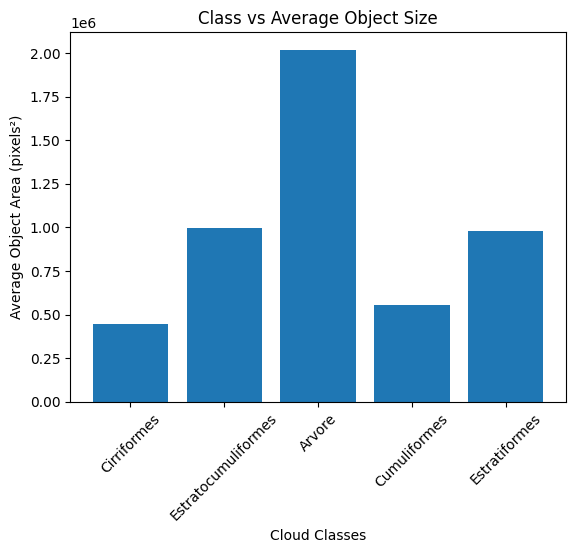

In [29]:

avg_areas = {k: np.mean(v) for k, v in class_areas.items()}

plt.bar(avg_areas.keys(), avg_areas.values())
plt.xticks(rotation=45)
plt.title("Class vs Average Object Size")
plt.xlabel("Cloud Classes")
plt.ylabel("Average Object Area (pixels²)")
plt.show()